# Ingredient-Supplier Scrapability Analysis

Goal: Find ingredients that have many suppliers with **good publicly available documentation** (TDS, COA, SDS) — best candidates for the Agnes quality verification demo.

In [1]:
import sqlite3
import json
import pandas as pd
from collections import defaultdict
from pathlib import Path

DB_PATH = Path('../data/db.sqlite')

## 1. Supplier Scrapability Scores

From manual research: how well each supplier publishes quality documents online.

In [2]:
# DB suppliers scrapability (from manual research)
db_supplier_scores = [
    {"supplier": "ADM", "access_level": "PARTIAL", "has_open_sds": True, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.45},
    {"supplier": "AIDP", "access_level": "REQUEST", "has_open_sds": False, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.10},
    {"supplier": "Actus Nutrition", "access_level": "REQUEST", "has_open_sds": False, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.10},
    {"supplier": "American Botanicals", "access_level": "REQUEST", "has_open_sds": False, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.10},
    {"supplier": "Ashland", "access_level": "OPEN", "has_open_sds": True, "has_open_tds": True, "has_coa_template": False, "scrapability_score": 0.75},
    {"supplier": "Balchem", "access_level": "OPEN", "has_open_sds": True, "has_open_tds": True, "has_coa_template": False, "scrapability_score": 0.70},
    {"supplier": "BulkSupplements", "access_level": "REQUEST", "has_open_sds": False, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.15},
    {"supplier": "Cambrex", "access_level": "MIXED", "has_open_sds": True, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.40},
    {"supplier": "Capsuline", "access_level": "REQUEST", "has_open_sds": False, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.05},
    {"supplier": "Cargill", "access_level": "OPEN", "has_open_sds": True, "has_open_tds": True, "has_coa_template": False, "scrapability_score": 0.70},
    {"supplier": "Colorcon", "access_level": "PARTIAL", "has_open_sds": True, "has_open_tds": True, "has_coa_template": False, "scrapability_score": 0.60},
    {"supplier": "Custom Probiotics", "access_level": "REQUEST", "has_open_sds": False, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.05},
    {"supplier": "Darling Ingredients / Rousselot", "access_level": "PARTIAL", "has_open_sds": True, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.50},
    {"supplier": "FutureCeuticals", "access_level": "MIXED", "has_open_sds": True, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.40},
    {"supplier": "Gold Coast Ingredients", "access_level": "MIXED", "has_open_sds": True, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.40},
    {"supplier": "IFF", "access_level": "OPEN", "has_open_sds": True, "has_open_tds": True, "has_coa_template": False, "scrapability_score": 0.75},
    {"supplier": "Icelandirect", "access_level": "REQUEST", "has_open_sds": False, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.10},
    {"supplier": "Ingredion", "access_level": "OPEN", "has_open_sds": True, "has_open_tds": True, "has_coa_template": False, "scrapability_score": 0.70},
    {"supplier": "Jost Chemical", "access_level": "OPEN", "has_open_sds": True, "has_open_tds": True, "has_coa_template": False, "scrapability_score": 0.75},
    {"supplier": "Koster Keunen", "access_level": "MIXED", "has_open_sds": True, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.40},
    {"supplier": "Magtein / ThreoTech LLC", "access_level": "REQUEST", "has_open_sds": False, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.05},
    {"supplier": "Makers Nutrition", "access_level": "REQUEST", "has_open_sds": False, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.05},
    {"supplier": "Mueggenburg USA", "access_level": "MIXED", "has_open_sds": True, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.40},
    {"supplier": "Nutra Blend", "access_level": "MIXED", "has_open_sds": True, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.40},
    {"supplier": "Nutra Food Ingredients", "access_level": "REQUEST", "has_open_sds": False, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.10},
    {"supplier": "Nutri Avenue", "access_level": "REQUEST", "has_open_sds": False, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.15},
    {"supplier": "Prinova USA", "access_level": "PARTIAL", "has_open_sds": True, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.50},
    {"supplier": "PureBulk", "access_level": "REQUEST", "has_open_sds": False, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.15},
    {"supplier": "Sawgrass Nutra Labs", "access_level": "REQUEST", "has_open_sds": False, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.05},
    {"supplier": "Sensient", "access_level": "OPEN", "has_open_sds": True, "has_open_tds": True, "has_coa_template": False, "scrapability_score": 0.75},
    {"supplier": "Source-Omega LLC", "access_level": "MIXED", "has_open_sds": True, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.40},
    {"supplier": "Specialty Enzymes & Probiotics", "access_level": "MIXED", "has_open_sds": True, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.40},
    {"supplier": "Spectrum Chemical", "access_level": "OPEN", "has_open_sds": True, "has_open_tds": True, "has_coa_template": True, "scrapability_score": 0.95},
    {"supplier": "Stauber", "access_level": "PARTIAL", "has_open_sds": True, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.50},
    {"supplier": "Strahl & Pitsch", "access_level": "PARTIAL", "has_open_sds": True, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.50},
    {"supplier": "TCI America", "access_level": "OPEN", "has_open_sds": True, "has_open_tds": True, "has_coa_template": False, "scrapability_score": 0.80},
    {"supplier": "Trace Minerals", "access_level": "PARTIAL", "has_open_sds": True, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.45},
    {"supplier": "Univar Solutions", "access_level": "OPEN", "has_open_sds": True, "has_open_tds": True, "has_coa_template": False, "scrapability_score": 0.80},
    {"supplier": "Virginia Dare", "access_level": "PARTIAL", "has_open_sds": True, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.50},
    {"supplier": "Vitaquest", "access_level": "REQUEST", "has_open_sds": False, "has_open_tds": False, "has_coa_template": False, "scrapability_score": 0.05}
]

# Non-DB suppliers with good scrapability
external_supplier_scores = [
    {"supplier": "Carl Roth", "access_level": "OPEN", "has_open_sds": True, "has_open_tds": True, "has_coa_template": True, "scrapability_score": 0.95},
    {"supplier": "Sigma-Aldrich / MilliporeSigma", "access_level": "OPEN", "has_open_sds": True, "has_open_tds": True, "has_coa_template": True, "scrapability_score": 0.95},
    {"supplier": "Thermo Fisher / Alfa Aesar", "access_level": "OPEN", "has_open_sds": True, "has_open_tds": True, "has_coa_template": True, "scrapability_score": 0.90},
    {"supplier": "DSM-Firmenich", "access_level": "OPEN", "has_open_sds": True, "has_open_tds": True, "has_coa_template": False, "scrapability_score": 0.80},
    {"supplier": "BASF", "access_level": "OPEN", "has_open_sds": True, "has_open_tds": True, "has_coa_template": False, "scrapability_score": 0.80},
    {"supplier": "Foodchem", "access_level": "OPEN", "has_open_sds": True, "has_open_tds": True, "has_coa_template": True, "scrapability_score": 0.85},
]

scrap_df = pd.DataFrame(db_supplier_scores + external_supplier_scores)
scrap_df = scrap_df.sort_values('scrapability_score', ascending=False)
print(f'Total suppliers with scrapability data: {len(scrap_df)}')
scrap_df.head(15)

Total suppliers with scrapability data: 46


,supplier,access_level,has_open_sds,has_open_tds,has_coa_template,scrapability_score
32,Spectrum Chemical,OPEN,True,True,True,0.95
41,Sigma-Aldrich / MilliporeSigma,OPEN,True,True,True,0.95
40,Carl Roth,OPEN,True,True,True,0.95
42,Thermo Fisher / Alfa Aesar,OPEN,True,True,True,0.90
45,Foodchem,OPEN,True,True,True,0.85
37,Univar Solutions,OPEN,True,True,False,0.80
44,BASF,OPEN,True,True,False,0.80
43,DSM-Firmenich,OPEN,True,True,False,0.80
35,TCI America,OPEN,True,True,False,0.80
18,Jost Chemical,OPEN,True,True,False,0.75


## 2. Map DB Ingredients to Suppliers

In [3]:
conn = sqlite3.connect(DB_PATH)

rows = conn.execute('''
    SELECT s.Name as supplier, p.SKU
    FROM Supplier s
    JOIN Supplier_Product sp ON s.Id = sp.SupplierId
    JOIN Product p ON sp.ProductId = p.Id
    WHERE p.Type = 'raw-material'
    ORDER BY s.Name, p.SKU
''').fetchall()

# Parse ingredient from SKU: RM-C{id}-{ingredient}-{hash}
ingredient_suppliers = defaultdict(set)
supplier_ingredients = defaultdict(set)

for supplier, sku in rows:
    parts = sku.split('-', 2)
    if len(parts) >= 3:
        ingredient = '-'.join(parts[2].rsplit('-', 1)[:-1])
        if ingredient:
            ingredient_suppliers[ingredient].add(supplier)
            supplier_ingredients[supplier].add(ingredient)

print(f'Unique ingredients: {len(ingredient_suppliers)}')
print(f'Unique suppliers: {len(supplier_ingredients)}')

Unique ingredients: 357
Unique suppliers: 40


## 3. Score Each Ingredient by Supplier Scrapability

For each ingredient, compute:
- Number of DB suppliers
- Average scrapability of those suppliers
- Number of suppliers with `has_open_tds = True`
- Number of suppliers with `scrapability_score >= 0.5`

The best demo ingredients are those with **multiple suppliers that have good public docs**.

In [4]:
# Build scrapability lookup as plain dicts (not pandas Series)
scrap_lookup = {row['supplier']: dict(row) for _, row in scrap_df.iterrows()}

ingredient_scores = []
for ingredient, suppliers in ingredient_suppliers.items():
    n_suppliers = len(suppliers)
    scores = []
    n_with_tds = 0
    n_good = 0  # scrapability >= 0.5
    supplier_details = []
    
    for s in suppliers:
        info = scrap_lookup.get(s)
        sc = info['scrapability_score'] if info else 0.0
        scores.append(sc)
        if info and info.get('has_open_tds', False):
            n_with_tds += 1
        if sc >= 0.5:
            n_good += 1
        supplier_details.append(f"{s} ({sc:.2f})")
    
    avg_score = sum(scores) / len(scores) if scores else 0.0
    max_score = max(scores) if scores else 0.0
    
    # Combined ranking: prioritize ingredients with MULTIPLE good suppliers
    demo_score = (n_good * 0.4) + (avg_score * 0.3) + (n_with_tds * 0.3)
    
    ingredient_scores.append({
        'ingredient': ingredient,
        'n_suppliers': n_suppliers,
        'n_good_suppliers': n_good,
        'n_with_tds': n_with_tds,
        'avg_scrapability': round(avg_score, 2),
        'max_scrapability': round(max_score, 2),
        'demo_score': round(demo_score, 2),
        'suppliers': ', '.join(sorted(supplier_details)),
    })

scores_df = pd.DataFrame(ingredient_scores)
scores_df = scores_df.sort_values('demo_score', ascending=False)
print(f'Scored {len(scores_df)} ingredients')

Scored 357 ingredients


## 4. Best Ingredients for Demo

Top ingredients ranked by demo_score = (n_good_suppliers × 0.4) + (avg_scrapability × 0.3) + (n_with_tds × 0.3)

In [5]:
# Show top 30 with good demo potential
top = scores_df.head(30)[['ingredient', 'n_suppliers', 'n_good_suppliers', 'n_with_tds', 'avg_scrapability', 'max_scrapability', 'demo_score', 'suppliers']]
top.style.format({'avg_scrapability': '{:.2f}', 'max_scrapability': '{:.2f}', 'demo_score': '{:.2f}'}).background_gradient(subset=['demo_score'], cmap='YlGn')

,ingredient,n_suppliers,n_good_suppliers,n_with_tds,avg_scrapability,max_scrapability,demo_score,suppliers
353,non-gmo-corn-zein,2,2,2,0.88,0.95,1.66,"Spectrum Chemical (0.95), TCI America (0.80)"
352,bht,2,2,2,0.88,0.95,1.66,"Spectrum Chemical (0.95), Univar Solutions (0.80)"
351,polyethylene-glycol,2,2,2,0.88,0.95,1.66,"Spectrum Chemical (0.95), Univar Solutions (0.80)"
64,talc,2,2,2,0.68,0.75,1.60,"Ashland (0.75), Colorcon (0.60)"
77,polyvinylpolypyrrolidone,2,2,2,0.68,0.75,1.60,"Ashland (0.75), Colorcon (0.60)"
55,cellulose,2,2,2,0.68,0.75,1.60,"Ashland (0.75), Colorcon (0.60)"
73,silicon-dioxide,2,2,2,0.68,0.75,1.60,"Ashland (0.75), Colorcon (0.60)"
74,potassium-alginate,2,2,2,0.68,0.75,1.60,"Ashland (0.75), Colorcon (0.60)"
75,vegetable-cellulose,2,2,2,0.68,0.75,1.60,"Ashland (0.75), Colorcon (0.60)"
76,organic-coating,2,2,2,0.68,0.75,1.60,"Ashland (0.75), Colorcon (0.60)"


## 5. Filter: Ingredients with >= 2 Good Suppliers

In [6]:
multi_good = scores_df[scores_df['n_good_suppliers'] >= 2].copy()
print(f'Ingredients with 2+ suppliers having scrapability >= 0.5: {len(multi_good)}')
if len(multi_good) > 0:
    display(multi_good[['ingredient', 'n_suppliers', 'n_good_suppliers', 'n_with_tds', 'avg_scrapability', 'demo_score', 'suppliers']])
else:
    print('None found — showing ingredients with at least 1 good supplier instead:')
    single_good = scores_df[scores_df['n_good_suppliers'] >= 1]
    display(single_good.head(20)[['ingredient', 'n_suppliers', 'n_good_suppliers', 'n_with_tds', 'avg_scrapability', 'demo_score', 'suppliers']])

Ingredients with 2+ suppliers having scrapability >= 0.5: 86


,ingredient,n_suppliers,n_good_suppliers,n_with_tds,avg_scrapability,demo_score,suppliers
353,non-gmo-corn-zein,2,2,2,0.88,1.66,"Spectrum Chemical (0.95), TCI America (0.80)"
352,bht,2,2,2,0.88,1.66,"Spectrum Chemical (0.95), Univar Solutions (0.80)"
351,polyethylene-glycol,2,2,2,0.88,1.66,"Spectrum Chemical (0.95), Univar Solutions (0.80)"
64,talc,2,2,2,0.68,1.60,"Ashland (0.75), Colorcon (0.60)"
77,polyvinylpolypyrrolidone,2,2,2,0.68,1.60,"Ashland (0.75), Colorcon (0.60)"
...,...,...,...,...,...,...,...
189,coconut-sugar,2,2,1,0.60,1.28,"Ingredion (0.70), Prinova USA (0.50)"
172,sugar,2,2,1,0.60,1.28,"Ingredion (0.70), Prinova USA (0.50)"
186,anhydrous-dextrose,2,2,1,0.60,1.28,"Ingredion (0.70), Prinova USA (0.50)"
117,monk-fruit-extract,2,2,1,0.60,1.28,"Cargill (0.70), Prinova USA (0.50)"


## 6. Supplier Scrapability Distribution

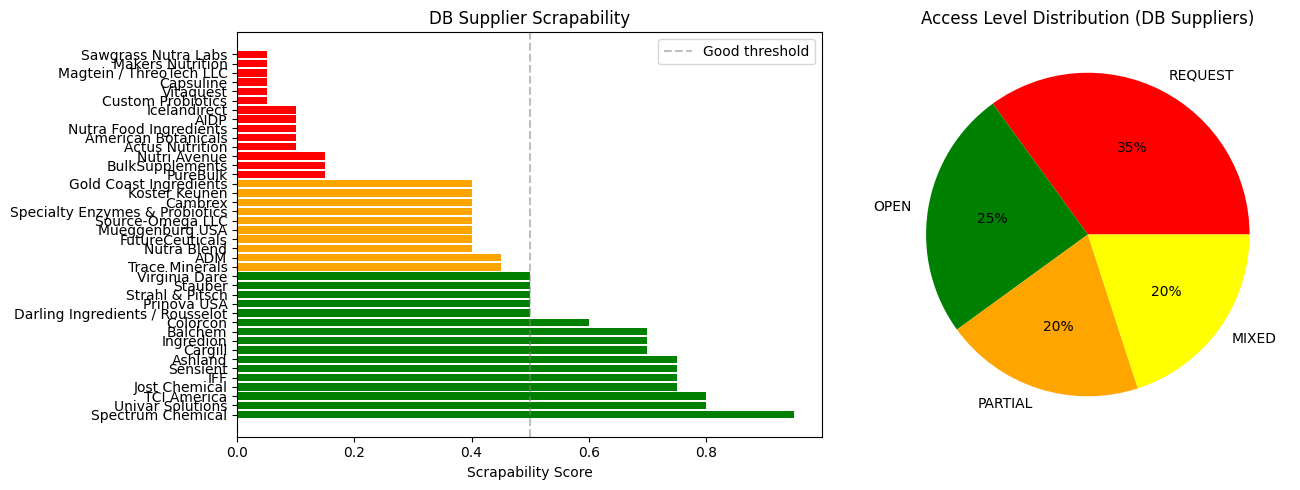

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: supplier scrapability distribution
db_only = scrap_df[scrap_df['supplier'].isin(supplier_ingredients.keys())]
axes[0].barh(db_only['supplier'], db_only['scrapability_score'], color=['green' if s >= 0.5 else 'orange' if s >= 0.3 else 'red' for s in db_only['scrapability_score']])
axes[0].set_xlabel('Scrapability Score')
axes[0].set_title('DB Supplier Scrapability')
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Good threshold')
axes[0].legend()

# Right: access level distribution
access_counts = scrap_df[scrap_df['supplier'].isin(supplier_ingredients.keys())]['access_level'].value_counts()
colors = {'OPEN': 'green', 'PARTIAL': 'orange', 'MIXED': 'yellow', 'REQUEST': 'red'}
axes[1].pie(access_counts.values, labels=access_counts.index, colors=[colors.get(l, 'gray') for l in access_counts.index], autopct='%1.0f%%')
axes[1].set_title('Access Level Distribution (DB Suppliers)')

plt.tight_layout()
plt.show()

## 7. Best Suppliers for Quality Verification Demo

Suppliers with OPEN access + TDS available = best for live demo.

In [8]:
best_suppliers = scrap_df[
    (scrap_df['scrapability_score'] >= 0.7) & 
    (scrap_df['has_open_tds'] == True)
].copy()

# Show which ingredients each best supplier carries
for _, row in best_suppliers.iterrows():
    s = row['supplier']
    ings = supplier_ingredients.get(s, set())
    if ings:
        print(f"\n{s} (score={row['scrapability_score']:.2f}, {row['access_level']}):")
        for ing in sorted(ings)[:10]:
            print(f"  - {ing}")
        if len(ings) > 10:
            print(f"  ... +{len(ings)-10} more")


Spectrum Chemical (score=0.95, OPEN):
  - bht
  - non-gmo-corn-zein
  - para-amino-benzoic-acid
  - polyethylene-glycol

Univar Solutions (score=0.80, OPEN):
  - bht
  - citric-acid
  - dl-tartaric-acid
  - lactic-acid
  - malic-acid
  - polyethylene-glycol
  - stevia-or-sucralose-sweetener
  - sucralose

TCI America (score=0.80, OPEN):
  - non-gmo-corn-zein

Jost Chemical (score=0.75, OPEN):
  - boron
  - calcium
  - calcium-carbonate
  - calcium-citrate
  - calcium-lactate-gluconate
  - chloride
  - chromium
  - chromium-chloride
  - chromium-nicotinate
  - chromium-picolinate
  ... +46 more

IFF (score=0.75, OPEN):
  - bifidobacterium-lactis-bl-04

Sensient (score=0.75, OPEN):
  - blue-2-lake
  - coloring-concentrates
  - fd-and-c-blue-no-2-lake
  - fd-and-c-red-no-40-lake
  - fd-and-c-yellow-no-6-lake
  - red-40-lake
  - yellow-6-lake

Ashland (score=0.75, OPEN):
  - aqueous-coating
  - carboxymethylcellulose-sodium
  - cellulose
  - croscarmellose-sodium
  - hydroxypropyl-methyl-

## 8. Recommended Demo Ingredients

Based on:
1. Multiple suppliers in DB
2. At least one supplier with high scrapability (TDS/COA available)
3. Common CPG ingredient (recognizable in demo)

In [9]:
# Final recommendations
print("=" * 60)
print("RECOMMENDED INGREDIENTS FOR AGNES DEMO")
print("=" * 60)

for _, row in scores_df.head(15).iterrows():
    ing = row['ingredient']
    suppliers = ingredient_suppliers[ing]
    good_sups = [s for s in suppliers if (scrap_lookup.get(s) or {}).get('scrapability_score', 0) >= 0.5]
    tds_sups = [s for s in suppliers if (scrap_lookup.get(s) or {}).get('has_open_tds', False)]
    
    status = '***' if row['n_good_suppliers'] >= 2 else '**' if row['n_good_suppliers'] >= 1 else '*'
    print(f"\n{status} {ing}")
    print(f"   Suppliers: {row['n_suppliers']} total, {row['n_good_suppliers']} good, {row['n_with_tds']} with TDS")
    print(f"   Demo score: {row['demo_score']:.2f}")
    if good_sups:
        print(f"   Good suppliers: {', '.join(good_sups)}")
    if tds_sups:
        print(f"   TDS available: {', '.join(tds_sups)}")

RECOMMENDED INGREDIENTS FOR AGNES DEMO

*** non-gmo-corn-zein
   Suppliers: 2 total, 2 good, 2 with TDS
   Demo score: 1.66
   Good suppliers: TCI America, Spectrum Chemical
   TDS available: TCI America, Spectrum Chemical

*** bht
   Suppliers: 2 total, 2 good, 2 with TDS
   Demo score: 1.66
   Good suppliers: Univar Solutions, Spectrum Chemical
   TDS available: Univar Solutions, Spectrum Chemical

*** polyethylene-glycol
   Suppliers: 2 total, 2 good, 2 with TDS
   Demo score: 1.66
   Good suppliers: Univar Solutions, Spectrum Chemical
   TDS available: Univar Solutions, Spectrum Chemical

*** talc
   Suppliers: 2 total, 2 good, 2 with TDS
   Demo score: 1.60
   Good suppliers: Colorcon, Ashland
   TDS available: Colorcon, Ashland

*** polyvinylpolypyrrolidone
   Suppliers: 2 total, 2 good, 2 with TDS
   Demo score: 1.60
   Good suppliers: Colorcon, Ashland
   TDS available: Colorcon, Ashland

*** cellulose
   Suppliers: 2 total, 2 good, 2 with TDS
   Demo score: 1.60
   Good suppli